# x28 Larger image features

With our more efficient method of handling images, we can now feasibly use larger image sizes (e.g., 100x100 pixels)

In [1]:
%load_ext autoreload
%autoreload 2

import pathlib
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Load Data

In [6]:
from generate_data_efficient import load_efficient_dataset
from pprint import pprint

output_dir = pathlib.Path('data/efficient')

# Load the efficient dataset
dataset = load_efficient_dataset(output_dir, include_image_features=True)
print(f"Loaded dataset with {len(dataset)} samples")
print("Metadata:")
pprint(dataset.metadata)

Loaded dataset with 1000 samples
Metadata:
{'image_dir': 'data\\01_nerf\\02_lego_large',
 'img_size': 100,
 'include_image_features': True,
 'model_path': 'output\\01_nerf\\02_lego_large\\1762043798762\\0',
 'num_samples': 1000,
 'random_seed': 42,
 'subset_size': 15,
 'translation_range': (-10.0, 10.0)}


# Data Loader

In [9]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

# Split into train/val/test (70-20-10)
train_size = int(len(dataset) * 0.7)
val_size = int(len(dataset) * 0.2)
test_size = len(dataset) - train_size - val_size  # Remainder for test

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

# Create DataLoaders
# train_loader = DataLoader(train_dataset, batch_size=36, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=36, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=36, shuffle=False)
#
# print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
# print(f"Val: {len(val_dataset)} samples, {len(val_loader)} batches")
# print(f"Test: {len(test_dataset)} samples, {len(test_loader)} batches")


Train: 700 samples, 20 batches
Val: 200 samples, 6 batches
Test: 100 samples, 3 batches


# Training Loop

In [13]:
from models.models import SiameseGAT_v7
import random
import roma
import numpy as np
from tqdm import tqdm
from hydra import compose, initialize
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
from utils.loss import compute_combined_loss, compute_angular_error

# Set seeds for reproducibility
torch.manual_seed(43)
random.seed(43)

# Load the config
with initialize(version_base=None, config_path="conf"):
    cfg = compose(
        # Load config
        config_name="config",
        # Override params programmatically
        overrides=[
            "model.embedding_size=64",
            "training.batch_size=32",
            "training.num_epochs=100",
            "training.lambda_frobenius=0.01",
            "training.lambda_translation=1.0",
            "training.lr=0.01"]
    )
    # Inspect what config was loaded
    print(OmegaConf.to_yaml(cfg))

# And we create a distinct DataLoader for each dataset train and val
train_loader = DataLoader(train_dataset, cfg.training.batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, cfg.training.batch_size, shuffle=False)

print(f"Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"Val: {len(val_dataset)} samples, {len(val_loader)} batches")

# View results by running in the terminal:
# tensorboard --logdir=runs
timestamp_str = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter(f'runs/x28_larger_image_features/{timestamp_str}')

# Log config
writer.add_text("config", OmegaConf.to_yaml(cfg))

# Get feature dimension from first sample
sample_graph_a, _, _, _ = dataset[0]
num_node_features = sample_graph_a.x.shape[1]

# Define the mode;
model = SiameseGAT_v7(
    num_node_features,
    graph_embedding_dim=cfg.model.embedding_size
).to(device)

# Log the model
writer.add_text("model", str(model))

# optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
# optimizer = torch.optim.SGD(model.parameters(), lr=cfg.training.lr, momentum=0.9)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.training.lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
criterion_translation = torch.nn.MSELoss()
criterion_rotation = torch.nn.L1Loss()

# Keep track of loss for logging
epoch_losses_train = []
epoch_losses_val = np.full(cfg.training.num_epochs, np.nan)  # one slot per epoch. makes plotting easier
with tqdm(range(cfg.training.num_epochs),desc=f"Training progress") as pbar:
    for epoch in pbar:
        model.train()
        train_loss_all = 0.0
        train_loss_translation = 0.0
        train_loss_rotation = 0.0
        train_angular_error = 0.0
        train_frobenius_norm = 0.0
        train_translation_error = 0.0
        for batch in train_loader:
            # Move data to the GPU
            graph_a_batch         = batch[0].to(device)
            graph_b_batch         = batch[1].to(device)
            labels_translations   = batch[2].to(device)
            labels_quat_xyzw      = batch[3].to(device)
            optimizer.zero_grad()
            pred_translation, pred_rotation_raw = model(graph_a_batch, graph_b_batch)
            # "Normalize" the predicted matrix so that it is a valid SO(3) rotation matrix
            pred_rotation = roma.special_procrustes(pred_rotation_raw)

            # Calculate Frobenius norm between pred_rotation_raw and pred_rotation
            # This measures how far the raw prediction is from the SO(3) manifold
            frobenius_norm = torch.norm(pred_rotation_raw - pred_rotation, p='fro', dim=(-2, -1)).mean()

            # Calculate losses using the helper function
            loss, loss_trans, loss_rotation = compute_combined_loss(
                pred_translation, pred_rotation, labels_translations, labels_quat_xyzw,
                criterion_translation, criterion_rotation, cfg.training.lambda_translation
            )

            # Add Frobenius norm as regularization term
            lambda_frobenius = cfg.training.lambda_frobenius
            loss = loss + lambda_frobenius * frobenius_norm
            # Calculate angular error
            true_rotmat = roma.unitquat_to_rotmat(labels_quat_xyzw)
            angular_error = compute_angular_error(pred_rotation, true_rotmat)
            train_angular_error += angular_error.mean().item()

            # Calculate translation error (L2 norm)
            translation_error = torch.norm(pred_translation - labels_translations, p=2, dim=-1).mean()
            train_translation_error += translation_error.item()

            # Compute gradient
            loss.backward()
            # update the weights
            optimizer.step()
            train_loss_all += loss.item()
            train_loss_translation += loss_trans.item()
            train_loss_rotation += loss_rotation.item()
            train_frobenius_norm += frobenius_norm.item()
        avg_loss = train_loss_all / len(train_loader)
        avg_loss_translation = train_loss_translation / len(train_loader)
        avg_loss_rotation = train_loss_rotation / len(train_loader)
        avg_angular_error = train_angular_error / len(train_loader)
        avg_frobenius_norm = train_frobenius_norm / len(train_loader)
        avg_translation_error = train_translation_error / len(train_loader)
        writer.add_scalar('loss_all/train', avg_loss, epoch)
        writer.add_scalar('loss_translation/train', avg_loss_translation, epoch)
        writer.add_scalar('loss_rotation/train', avg_loss_rotation, epoch)
        writer.add_scalar('angular_error/train', avg_angular_error, epoch)
        writer.add_scalar('frobenius_norm/train', avg_frobenius_norm, epoch)
        writer.add_scalar('translation_error/train', avg_translation_error, epoch)
        epoch_losses_train.append(avg_loss)
        pbar.set_postfix({'loss': f'{avg_loss:.4f}', 'loss_trans': f'{avg_loss_translation:.4f}', 'loss_rot:': f'{avg_loss_rotation:.4f}', 'ang_err': f'{avg_angular_error:.2f}°', 'frob': f'{avg_frobenius_norm:.4f}' })
        # learning rate decay
        if scheduler is not None:
            scheduler.step()

        # Validation
        if epoch % 10 == 0:
            model.eval()
            val_loss = 0.0
            val_loss_translation = 0.0
            val_loss_rotation = 0.0
            val_angular_error = 0.0
            val_frobenius_norm = 0.0
            val_translation_error = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    graph_a_batch = batch[0].to(device)
                    graph_b_batch = batch[1].to(device)
                    labels_translations   = batch[2].to(device)
                    labels_quat_xyzw   = batch[3].to(device)
                    pred_translation, pred_rotation_raw = model(graph_a_batch, graph_b_batch)
                    # "Normalize" the predicted matrix so that it is a valid SO(3) rotation matrix
                    pred_rotation = roma.special_procrustes(pred_rotation_raw)

                    # Calculate Frobenius norm between pred_rotation_raw and pred_rotation
                    frobenius_norm = torch.norm(pred_rotation_raw - pred_rotation, p='fro', dim=(-2, -1)).mean()

                    # Calculate losses using the helper function
                    loss, loss_trans, loss_rotation = compute_combined_loss(
                        pred_translation, pred_rotation, labels_translations, labels_quat_xyzw,
                        criterion_translation, criterion_rotation, cfg.training.lambda_translation
                    )

                    # Add Frobenius norm as regularization term
                    lambda_frobenius = cfg.training.lambda_frobenius  # Weight for the regularization term
                    loss = loss + lambda_frobenius * frobenius_norm

                    # Calculate angular error
                    true_rotmat = roma.unitquat_to_rotmat(labels_quat_xyzw)
                    angular_error = compute_angular_error(pred_rotation, true_rotmat)
                    val_angular_error += angular_error.mean().item()

                    # Calculate translation error (L2 norm)
                    translation_error = torch.norm(pred_translation - labels_translations, p=2, dim=-1).mean()
                    val_translation_error += translation_error.item()

                    val_loss += loss.item()
                    val_loss_translation += loss_trans.item()
                    val_loss_rotation += loss_rotation.item()
                    val_frobenius_norm += frobenius_norm.item()
                avg_val_loss = val_loss / len(val_loader)
                avg_val_loss_translation = val_loss_translation / len(val_loader)
                avg_val_loss_rotation = val_loss_rotation / len(val_loader)
                avg_val_angular_error = val_angular_error / len(val_loader)
                avg_val_frobenius_norm = val_frobenius_norm / len(val_loader)
                avg_val_translation_error = val_translation_error / len(val_loader)
                epoch_losses_val[epoch] = avg_val_loss
                writer.add_scalar('loss_all/val', avg_val_loss, epoch)
                writer.add_scalar('loss_translation/val', avg_val_loss_translation, epoch)
                writer.add_scalar('loss_rotation/val', avg_val_loss_rotation, epoch)
                writer.add_scalar('angular_error/val', avg_val_angular_error, epoch)
                writer.add_scalar('frobenius_norm/val', avg_val_frobenius_norm, epoch)
                writer.add_scalar('translation_error/val', avg_val_translation_error, epoch)

model:
  embedding_size: 64
training:
  num_epochs: 100
  batch_size: 32
  lr: 0.01
  lambda_translation: 1.0
  lambda_frobenius: 0.01

Train: 700 samples, 22 batches
Val: 200 samples, 7 batches


Training progress: 100%|██████████| 100/100 [05:40<00:00,  3.41s/it, loss=33.7430, loss_trans=33.0878, loss_rot:=0.6552, ang_err=125.36°, frob=0.0012]


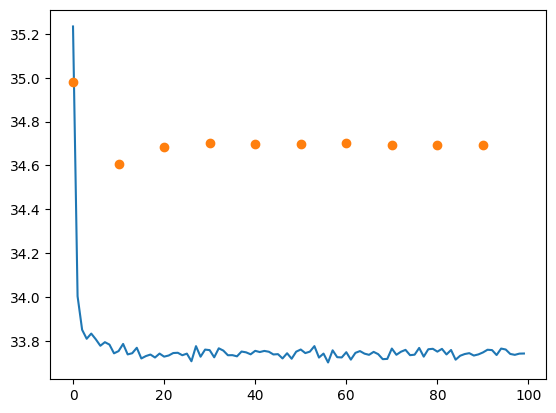

In [14]:
# Plot the results!
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epoch_losses_train)
plt.plot(epoch_losses_val, marker='o')
plt.show()

# Visualize Prediction

In [ ]:
import utils.vis

# Use the new helper function to visualize predictions
# sample = train_dataset[15]
sample = val_dataset[0]
predicted_graph_b, true_graph_b, graph_a, graph_b = utils.vis.visualize_sfm_prediction(model, sample)